# **Processamento Digital de Sinais — 1ª Avaliação**



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Todos os gráficos são salvos nesta pasta (criada se não existir)
IMAGES_DIR = 'images'
os.makedirs(IMAGES_DIR, exist_ok=True)

## Questão 1

### a) O sinal é periódico? Qual o período?

Um sinal senoidal discreto $x[n] = A\cos(\omega_0 n + \theta)$ é periódico se existir um inteiro $N > 0$ tal que $x[n] = x[n+N]$ para todo $n$. Impondo essa condição:

$$A\cos(\omega_0 n + \theta) = A\cos\big(\omega_0(n+N) + \theta\big) = A\cos(\omega_0 n + \omega_0 N + \theta)$$

A igualdade vale quando $\omega_0 N$ é múltiplo inteiro de $2\pi$, ou seja, o sinal é periódico se e somente se

$$\omega_0 N = 2\pi r, \quad \text{com } N, r \text{ inteiros.}$$

Aqui $\omega_0 = \dfrac{12\pi}{5}$ e $\theta = 0$. Substituindo:

$$\frac{12\pi}{5}N = 2\pi r \;\Longrightarrow\; N = \frac{2\pi r \cdot 5}{12\pi} = \frac{5r}{6}$$

Como $N$ precisa ser inteiro e $5$ e $6$ são primos entre si, $r$ deve ser múltiplo de $6$. O menor inteiro positivo é $r = 6$, que dá

$$N = \frac{5 \cdot 6}{6} = 5.$$

Portanto, **$x[n]$ é periódico com período fundamental $N = 5$**.

**Verificação direta:**

$$x[n+5] = \cos\!\left(\frac{12\pi}{5}(n+5)\right) = \cos\!\left(\frac{12\pi}{5}n + 12\pi\right) = \cos\!\left(\frac{12\pi}{5}n\right) = x[n] \; \checkmark$$

pois $12\pi$ é múltiplo inteiro de $2\pi$ ($12\pi = 6 \cdot 2\pi$).

**Frequência equivalente.** Vale notar que $\omega_0 = \frac{12\pi}{5} = 2{,}4\pi$ está fora do intervalo fundamental $-\pi < \omega \le \pi$. Como exponenciais/senoides discretas com frequências separadas de $2\pi$ são **indistinguíveis**, temos

$$\omega_0 = 2{,}4\pi \equiv 2{,}4\pi - 2\pi = 0{,}4\pi,$$

isto é, $x[n] = \cos(0{,}4\pi n)$ — o que dá o mesmo período: $0{,}4\pi N = 2\pi r \Rightarrow N = 5r \Rightarrow N = 5$. Essa observação será a chave para explicar o item (b).

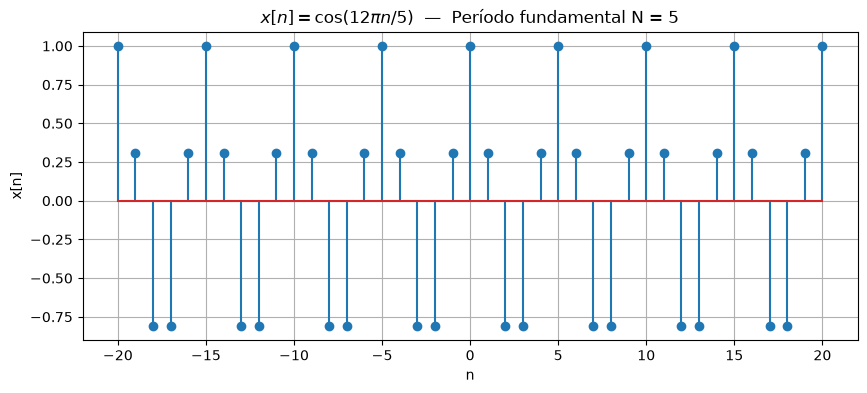

In [2]:
n = np.arange(-20, 21)
x = np.cos((12*np.pi/5)*n)

plt.figure(figsize=(10, 4))
plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title(r'$x[n] = \cos(12\pi n / 5)$  —  Período fundamental N = 5')
plt.grid(True)
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_1a.png'), dpi=150, bbox_inches='tight')
plt.show()

### b) Efeito da multiplicação da frequência no período

**Frequência multiplicada por 2:** $\omega_0' = 2 \cdot \dfrac{12\pi}{5} = \dfrac{24\pi}{5}$

$$\frac{24\pi}{5}N = 2\pi r \;\Longrightarrow\; N = \frac{5r}{12}$$

$N$ inteiro exige $r$ múltiplo de $12$; o menor é $r = 12$, dando $N = 5$. **O período não muda.**

*Por quê?* Usando a frequência equivalente: $\omega_0' = 4{,}8\pi \equiv 4{,}8\pi - 4\pi = 0{,}8\pi$. Ou seja, $x_2[n] = \cos(0{,}8\pi n)$. Dobrar $\omega_0$ levou a frequência de $0{,}4\pi$ para $0{,}8\pi$ — ainda dentro de $(0, \pi)$ — e o período continua $5$ porque $0{,}8\pi N = 2\pi r \Rightarrow N = 2{,}5r \Rightarrow r = 2, N = 5$.

**Frequência multiplicada por 5:** $\omega_0'' = 5 \cdot \dfrac{12\pi}{5} = 12\pi$

$$12\pi N = 2\pi r \;\Longrightarrow\; N = \frac{r}{6}$$

O menor $r$ que torna $N$ inteiro positivo é $r = 6$, dando $N = 1$.

*Por quê?* $\omega_0'' = 12\pi \equiv 12\pi - 12\pi = 0$. A frequência equivalente é **zero**: $\cos(12\pi n) = 1$ para todo $n$ inteiro, pois $12\pi n$ é sempre múltiplo de $2\pi$. O sinal vira uma **constante**, cujo período fundamental é o trivial $N = 1$.

**Conclusão.** Nos sinais **contínuos**, $T = 2\pi/\omega_0$: aumentar a frequência sempre diminui o período, na proporção inversa. Nos sinais **discretos** essa relação não vale — como acabamos de ver, dobrar a frequência manteve $N = 5$ e quintuplicá-la reduziu o sinal a uma constante. A razão é que apenas a frequência **módulo $2\pi$** importa, e o período precisa ser um número **inteiro** de amostras.

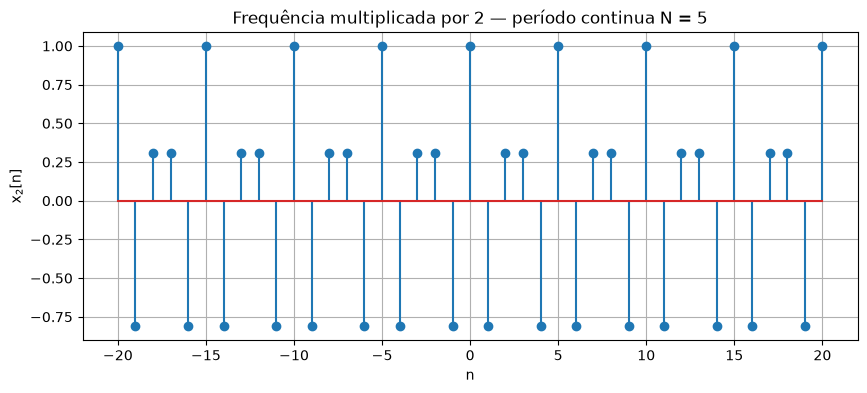

In [3]:
n = np.arange(-20, 21)

x2 = np.cos(2*(12*np.pi/5)*n)   # frequência x2

plt.figure(figsize=(10, 4))
plt.stem(n, x2)
plt.xlabel('n')
plt.ylabel('x$_2$[n]')
plt.title('Frequência multiplicada por 2 — período continua N = 5')
plt.grid(True)
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_1b_x2.png'), dpi=150, bbox_inches='tight')
plt.show()

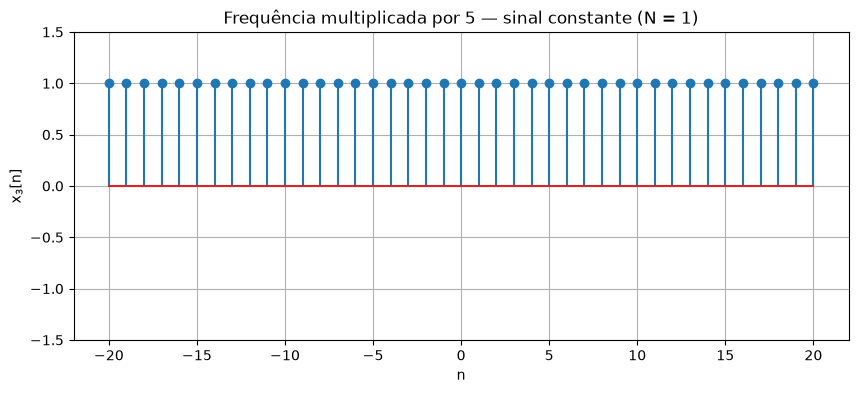

In [4]:
x3 = np.cos(5*(12*np.pi/5)*n)   # frequência x5

plt.figure(figsize=(10, 4))
plt.stem(n, x3)
plt.xlabel('n')
plt.ylabel('x$_3$[n]')
plt.title('Frequência multiplicada por 5 — sinal constante (N = 1)')
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_1b_x5.png'), dpi=150, bbox_inches='tight')
plt.show()

## Questão 2

Implementação da função `Deslocamento_Tempo(x, n, n0)`, que retorna $y[n] = x[n - n_0]$. A função funciona para qualquer vetor $x$, vetor de índices $n$ e escalar $n_0$ (positivo, negativo ou nulo).

In [5]:
def Deslocamento_Tempo(x, n, n0):
    """
    Retorna y tal que y[n] = x[n - n0], usando o MESMO vetor de indices n.
    Para cada indice n[i], busca o valor de x no indice (n[i] - n0);
    se esse indice nao existir no dominio original de x, o valor fica 0.
    x  : vetor com as amostras do sinal
    n  : vetor de indices correspondente a x
    n0 : escalar com o deslocamento (n0 > 0: atraso, n0 < 0: avanco)
    """
    x = np.asarray(x)
    n = np.asarray(n)
    if x.size != n.size:
        raise ValueError("x e n devem ter o mesmo tamanho.")

    y = np.zeros(n.size, dtype=float)
    for i, ni in enumerate(n):
        alvo = ni - n0
        pos = np.where(n == alvo)[0]
        if pos.size > 0:
            y[i] = x[pos[0]]
    return y

### Exemplo

Sinal de exemplo: $n \in [-3, 5]$ e $x[n]$ um pulso triangular, com $n_0 = 3$ (atraso de 3 amostras). Como $y[n] = x[n-n_0]$ é calculado internamente pela função (buscando o valor de $x$ no índice $n-n_0$ e preenchendo com zero fora do domínio original), $x$ e $y$ já ficam definidos sobre o **mesmo** vetor de índices $n$, podendo ser plotados diretamente no mesmo eixo.

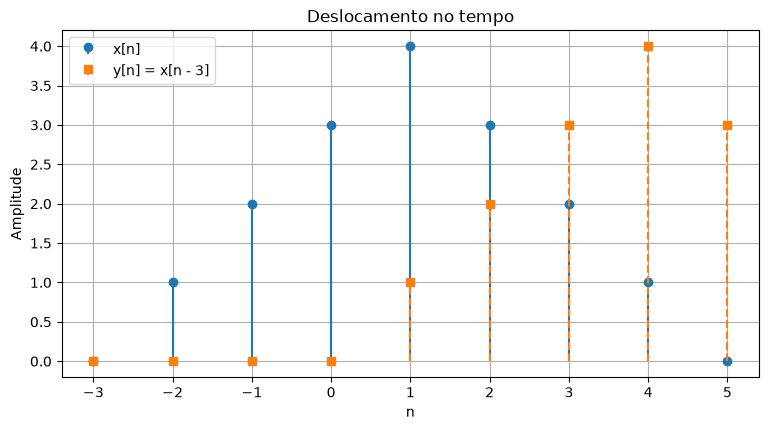

In [6]:
n = np.arange(-3, 6)
x = np.array([0, 1, 2, 3, 4, 3, 2, 1, 0])
n0 = 3
y = Deslocamento_Tempo(x, n, n0)

plt.figure(figsize=(9, 4.5))
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='x[n]')
plt.stem(n, y, linefmt='C1--', markerfmt='C1s', basefmt=' ', label=f'y[n] = x[n - {n0}]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title('Deslocamento no tempo')
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_2.png'), dpi=150, bbox_inches='tight')
plt.show()

## Questão 3

Para um sistema linear e invariante no tempo, a saída é a convolução entre a entrada $x[n]$ e a resposta ao impulso $h[n]$:

$$y[n]=(x*h)[n]=\sum_{k=-\infty}^{\infty}x[k]h[n-k].$$

Como os sinais são causais, $x[n]=h[n]=0$ para $n<0$, e o somatório se reduz a

$$y[n]=\sum_{k=0}^{n}x[k]h[n-k].$$

Se `x` possui $N_x$ amostras e `h` possui $N_h$ amostras, a saída completa possui $N_x+N_h-1$ amostras. A implementação calcula diretamente cada produto $x[k]h[m]$ e o acumula em $y[k+m]$, sem usar funções prontas de convolução.

In [7]:
def Convolucao(x, h):
    """Calcula a convolução completa de dois sinais causais sem np.convolve."""
    x = np.asarray(x)
    h = np.asarray(h)

    if x.ndim != 1 or h.ndim != 1:
        raise ValueError("x e h devem ser vetores unidimensionais.")
    if x.size == 0 or h.size == 0:
        raise ValueError("x e h não podem ser vetores vazios.")

    tipo = np.result_type(x.dtype, h.dtype)
    y = np.zeros(x.size + h.size - 1, dtype=tipo)

    for k in range(x.size):
        for m in range(h.size):
            y[k + m] += x[k] * h[m]

    return y

### Exemplo

Para $x[n]=\{1, 2 ,3\}$ e $h[n]=\{1,0{,}5\}$, com ambos começando em $n=0$, espera-se $y[n]=\{1; 2{,}5; 4; 1{,}5\}$.

In [8]:
x_exemplo = np.array([1, 2, 3])
h_exemplo = np.array([1, 0.5])
y_exemplo = Convolucao(x_exemplo, h_exemplo)

print("x[n] =", x_exemplo)
print("h[n] =", h_exemplo)
print("y[n] =", y_exemplo)

x[n] = [1 2 3]
h[n] = [1.  0.5]
y[n] = [1.  2.5 4.  1.5]


## Questão 4

A equação dada pode ser escrita como

$$y[n]=(1+r)y[n-1]+x[n].$$

Definindo $a=1+r$, a resposta ao impulso do sistema é $h[n]=a^n u[n]$. Como o aporte é constante e começa no primeiro mês, $x[n]=x\,u[n-1]$. A resposta total é a soma da resposta à condição inicial com a convolução dos aportes e da resposta ao impulso:

$$y[n]=a^ny_0+\sum_{k=1}^{n}x\,h[n-k]=a^ny_0+x\sum_{m=0}^{n-1}a^m.$$

Logo, para $r\neq0$,

$$\boxed{y[n]=y_0(1+r)^n+x\frac{(1+r)^n-1}{r}}.$$

Para $r=0$, a expressão se reduz a $\boxed{y[n]=y_0+nx}$. Assim, a implementação abaixo é uma solução fechada, e não uma iteração recursiva. A taxa deve ser informada na forma decimal (por exemplo, `0.01` para 1% ao mês).

In [9]:
def Investimento(y0, r, x, n):
    """Calcula o saldo apos n meses pela solucao fechada da equacao de diferenca.

    y0 : valor inicial do investimento
    r  : rentabilidade mensal em forma decimal (0.01 = 1% ao mes)
    x  : valor do aporte mensal (feito ao final de cada mes)
    n  : quantidade de meses
    """
    if n < 0:
        raise ValueError("n nao pode ser negativo.")
    if r <= -1:
        raise ValueError("r deve ser maior que -1.")

    if r == 0:
        return y0 + n*x

    fator = (1 + r)**n                  # (1+r)^n
    return y0*fator + x*(fator - 1)/r   # y0(1+r)^n + x[(1+r)^n - 1]/r

### Exemplo

Investimento inicial de R$ 1.000,00, rentabilidade de 1% ao mês, aporte mensal de R$ 200,00 e prazo de 12 meses.

In [10]:
valor = Investimento(1000, 0.01, 200, 12)
print(f"Valor final do investimento: R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

Valor final do investimento: R$ 3.663,33


## Questão 5

Dada a equação de diferenças

$$y[n] = 0{,}038\,x[n-1] + 0{,}034\,x[n-2] + 1{,}63\,y[n-1] - 0{,}70\,y[n-2].$$

### a) Função de transferência $H(z)$

**Inicialmente, temos que escrever a equação na forma padrão.** Passando os termos de saída para o lado esquerdo:

$$y[n] - 1{,}63\,y[n-1] + 0{,}70\,y[n-2] = 0{,}038\,x[n-1] + 0{,}034\,x[n-2].$$

**Após isso, vamos aplicar a transformada $z$.** Usando a propriedade do deslocamento, $x[n-k] \leftrightarrow z^{-k}X(z)$ (válida com condições iniciais nulas, que é a hipótese usada para definir a função de transferência):

$$Y(z) - 1{,}63\,z^{-1}Y(z) + 0{,}70\,z^{-2}Y(z) = 0{,}038\,z^{-1}X(z) + 0{,}034\,z^{-2}X(z).$$

**Depois, vamos colocar $Y(z)$ e $X(z)$ em evidência:**

$$Y(z)\left(1 - 1{,}63\,z^{-1} + 0{,}70\,z^{-2}\right) = X(z)\left(0{,}038\,z^{-1} + 0{,}034\,z^{-2}\right).$$

**Por fim, isolar a razão $Y(z)/X(z)$:**

$$\boxed{H(z) = \frac{Y(z)}{X(z)} = \frac{0{,}038\,z^{-1} + 0{,}034\,z^{-2}}{1 - 1{,}63\,z^{-1} + 0{,}70\,z^{-2}}}$$

Multiplicando numerador e denominador por $z^{2}$, obtém-se a forma em potências positivas:

$$H(z) = \frac{0{,}038\,z + 0{,}034}{z^{2} - 1{,}63\,z + 0{,}70}.$$

**Polos e zeros.** O zero finito vem de $0{,}038z + 0{,}034 = 0$, isto é, $z = -0{,}034/0{,}038 = -0{,}895$. Os polos vêm de $z^{2} - 1{,}63z + 0{,}70 = 0$:

$$z = \frac{1{,}63 \pm \sqrt{1{,}63^{2} - 4(0{,}70)}}{2} = \frac{1{,}63 \pm \sqrt{-0{,}1431}}{2} = 0{,}815 \pm 0{,}189j.$$

Como o produto das raízes de $z^2-1{,}63z+0{,}70$ é o termo independente, $z_1 z_2 = |z|^2 = 0{,}70$, logo

$$|z| = \sqrt{0{,}70} \approx 0{,}8367 < 1.$$

**Região de convergência e estabilidade.** O sistema é causal (a saída depende apenas de amostras passadas), então a RDC é $|z| > 0{,}8367$, isto é, o exterior do círculo que passa pelos polos. Como essa RDC **contém o círculo unitário** $|z| = 1$, o sistema é BIBO-estável e a resposta em frequência $H(e^{j\omega})$ existe — condição necessária para os itens seguintes.

### b) Representação de $H(z)$ em função da frequência

A resposta em frequência é obtida avaliando $H(z)$ sobre o círculo unitário, ou seja, fazendo $z = e^{j\omega}$ (passo legítimo porque a RDC contém $|z|=1$):

$$H(e^{j\omega}) = \frac{0{,}038\,e^{-j\omega} + 0{,}034\,e^{-j2\omega}}{1 - 1{,}63\,e^{-j\omega} + 0{,}70\,e^{-j2\omega}} = \frac{N(e^{j\omega})}{D(e^{j\omega})}.$$

**Separando parte real e imaginária.** Aplicando a fórmula de Euler, $e^{-jk\omega} = \cos(k\omega) - j\,\mathrm{sen}(k\omega)$:

$$N(e^{j\omega}) = \underbrace{\big[0{,}038\cos\omega + 0{,}034\cos 2\omega\big]}_{N_R(\omega)} + j\underbrace{\big[-0{,}038\,\mathrm{sen}\,\omega - 0{,}034\,\mathrm{sen}\,2\omega\big]}_{N_I(\omega)}$$

$$D(e^{j\omega}) = \underbrace{\big[1 - 1{,}63\cos\omega + 0{,}70\cos 2\omega\big]}_{D_R(\omega)} + j\underbrace{\big[1{,}63\,\mathrm{sen}\,\omega - 0{,}70\,\mathrm{sen}\,2\omega\big]}_{D_I(\omega)}$$

Como o módulo de um quociente é o quociente dos módulos e a fase de um quociente é a diferença das fases:

$$\boxed{\left|H(e^{j\omega})\right| = \frac{\sqrt{N_R^2(\omega) + N_I^2(\omega)}}{\sqrt{D_R^2(\omega) + D_I^2(\omega)}}}
\qquad
\boxed{\angle H(e^{j\omega}) = \operatorname{arctg}\frac{N_I(\omega)}{N_R(\omega)} - \operatorname{arctg}\frac{D_I(\omega)}{D_R(\omega)}}$$

(nas contas numéricas usa-se `arctan2`, que resolve corretamente o quadrante.)

**Forma compacta da magnitude via $|H|^2 = H H^{*}$.** Colocando $e^{-j\omega}$ em evidência no numerador, $N = e^{-j\omega}\big(0{,}038 + 0{,}034\,e^{-j\omega}\big)$, e como $|e^{-j\omega}| = 1$:

$$|N|^2 = \left|0{,}038 + 0{,}034e^{-j\omega}\right|^2 = 0{,}038^2 + 0{,}034^2 + 2(0{,}038)(0{,}034)\cos\omega = 0{,}002600 + 0{,}002584\cos\omega.$$

Fazendo $|D|^2 = D D^{*}$ e usando $e^{-jk\omega} + e^{jk\omega} = 2\cos k\omega$:

$$|D|^2 = \big(1 + 1{,}63^2 + 0{,}70^2\big) - 2\big(1{,}63 + 1{,}63 \cdot 0{,}70\big)\cos\omega + 2(0{,}70)\cos 2\omega$$
$$|D|^2 = 4{,}1469 - 5{,}542\cos\omega + 1{,}40\cos 2\omega.$$

Portanto, a magnitude em função da frequência é

$$\boxed{\left|H(e^{j\omega})\right| = \sqrt{\frac{0{,}002600 + 0{,}002584\cos\omega}{4{,}1469 - 5{,}542\cos\omega + 1{,}40\cos 2\omega}}}$$

Ambas as formas são equivalentes (verificado numericamente na célula do item **c**, com erro da ordem de $10^{-13}$).

**Observação sobre o intervalo de $\omega$.** Como os coeficientes da equação de diferenças são reais, vale a simetria hermitiana $H(e^{-j\omega}) = H^{*}(e^{j\omega})$: a magnitude é **par** e a fase é **ímpar**. Além disso, $H(e^{j\omega})$ é periódica de período $2\pi$. Por isso basta representar $\omega$ no intervalo $-\pi < \omega \le \pi$, e toda a informação já está contida em $0 \le \omega \le \pi$.

### c) Gráficos da magnitude e da fase de $H(e^{j\omega})$

Erro máximo entre |H| numérico e a fórmula fechada do item (b): 8.93e-14
Ganho em w=0 (contínuo): |H(e^j0)|   = 1.0286
Ganho em w=pi (Nyquist): |H(e^jpi)|  = 0.0012


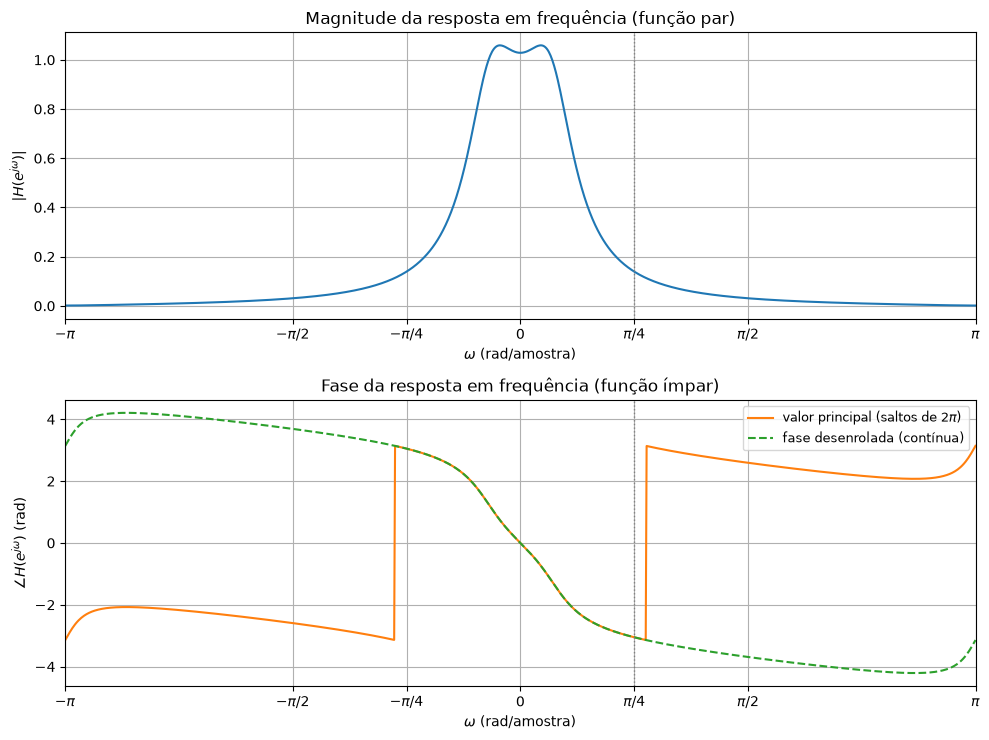

In [11]:
# Coeficientes da equação de diferenças, na forma padrão
# y[n] - 1.63 y[n-1] + 0.70 y[n-2] = 0.038 x[n-1] + 0.034 x[n-2]
b = np.array([0.0, 0.038, 0.034])   # numerador   -> x[n], x[n-1], x[n-2]
a = np.array([1.0, -1.63, 0.70])    # denominador -> y[n], y[n-1], y[n-2]


def resposta_frequencia(w):
    """Avalia H(e^{jw}) = N(e^{jw}) / D(e^{jw}) para um vetor de frequências w."""
    e1 = np.exp(-1j*w)      # e^{-jw}
    e2 = np.exp(-2j*w)      # e^{-j2w}
    N = b[0] + b[1]*e1 + b[2]*e2
    D = a[0] + a[1]*e1 + a[2]*e2
    return N/D


# Intervalo -pi < w <= pi (intervalo fundamental: H é periódica de período 2*pi)
w = np.linspace(-np.pi, np.pi, 1025)
H = resposta_frequencia(w)

mag = np.abs(H)
fase = np.angle(H)      # valor principal, sempre em (-pi, pi]

# Fase "desenrolada": remove os saltos artificiais de 2*pi do valor principal,
# deixando a curva contínua. O ajuste final garante fase(0) = 0.
fase_unwrap = np.unwrap(fase)
fase_unwrap -= fase_unwrap[np.argmin(np.abs(w))]

# --- Conferência das fórmulas fechadas deduzidas no item (b) ---
mag_formula = np.sqrt((0.038**2 + 0.034**2 + 2*0.038*0.034*np.cos(w)) /
                      (4.1469 - 5.542*np.cos(w) + 1.40*np.cos(2*w)))
print("Erro máximo entre |H| numérico e a fórmula fechada do item (b):",
      f"{np.max(np.abs(mag_formula - mag)):.2e}")
print(f"Ganho em w=0 (contínuo): |H(e^j0)|   = {np.abs(resposta_frequencia(np.array([0.0])))[0]:.4f}")
print(f"Ganho em w=pi (Nyquist): |H(e^jpi)|  = {np.abs(resposta_frequencia(np.array([np.pi])))[0]:.4f}")

# --- Gráficos ---
ticks = [-np.pi, -np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2, np.pi]
rotulos = [r'$-\pi$', r'$-\pi/2$', r'$-\pi/4$', '0', r'$\pi/4$', r'$\pi/2$', r'$\pi$']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7.5))

ax1.plot(w, mag, 'C0')
ax1.axvline(np.pi/4, color='gray', ls=':', lw=1)
ax1.set_xlabel(r'$\omega$ (rad/amostra)')
ax1.set_ylabel(r'$|H(e^{j\omega})|$')
ax1.set_title('Magnitude da resposta em frequência (função par)')
ax1.set_xlim(-np.pi, np.pi)
ax1.set_xticks(ticks)
ax1.set_xticklabels(rotulos)
ax1.grid(True)

ax2.plot(w, fase, 'C1', label='valor principal (saltos de $2\\pi$)')
ax2.plot(w, fase_unwrap, 'C2--', label='fase desenrolada (contínua)')
ax2.axvline(np.pi/4, color='gray', ls=':', lw=1)
ax2.set_xlabel(r'$\omega$ (rad/amostra)')
ax2.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax2.set_title('Fase da resposta em frequência (função ímpar)')
ax2.set_xlim(-np.pi, np.pi)
ax2.set_xticks(ticks)
ax2.set_xticklabels(rotulos)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_5_mag_fase.png'), dpi=150, bbox_inches='tight')
plt.show()

### d) Saída para a entrada $x[n] = \cos\!\left(\dfrac{\pi}{4}n\right)$

**Propriedade utilizada.** Para um sistema LIT estável, uma exponencial complexa é autofunção: se a entrada é $e^{j\omega_0 n}$, a saída é $H(e^{j\omega_0})\,e^{j\omega_0 n}$. Escrevendo o cosseno como soma de exponenciais e usando a simetria hermitiana ($H(e^{-j\omega}) = H^*(e^{j\omega})$, pois os coeficientes são reais), obtém-se o resultado clássico: para $x[n] = \cos(\omega_0 n)$,

$$y[n] = \left|H(e^{j\omega_0})\right|\,\cos\!\big(\omega_0 n + \angle H(e^{j\omega_0})\big).$$

Ou seja, o sistema **não cria novas frequências**: apenas escala a amplitude por $|H|$ e desloca a fase por $\angle H$.

**Primeiro, identifica-se a frequência.** Comparando $x[n]=\cos(\pi n/4)$ com $\cos(\omega_0 n)$, tem-se $\omega_0 = \dfrac{\pi}{4}$.

**Depois, vamos avaliar as exponenciais.**

$$e^{-j\pi/4} = \cos\tfrac{\pi}{4} - j\,\mathrm{sen}\tfrac{\pi}{4} = 0{,}70711 - 0{,}70711j,
\qquad e^{-j\pi/2} = -j.$$

**Após isso, vamos calcular numerador e denominador.**

$$N = 0{,}038(0{,}70711 - 0{,}70711j) + 0{,}034(-j) = 0{,}026870 - 0{,}060870j$$

$$D = 1 - 1{,}63(0{,}70711 - 0{,}70711j) + 0{,}70(-j) = 1 - 1{,}152584 + 1{,}152584j - 0{,}70j = -0{,}152584 + 0{,}452584j$$

**Módulos e fases.**

$$|N| = \sqrt{0{,}026870^2 + 0{,}060870^2} = 0{,}066537, \qquad \angle N = \operatorname{arctg2}(-0{,}060870;\ 0{,}026870) = -1{,}15509\ \text{rad}$$

$$|D| = \sqrt{0{,}152584^2 + 0{,}452584^2} = 0{,}477613, \qquad \angle D = \operatorname{arctg2}(0{,}452584;\ -0{,}152584) = +1{,}89597\ \text{rad}$$

**Por fim, combinar.**

$$\left|H(e^{j\pi/4})\right| = \frac{|N|}{|D|} = \frac{0{,}066537}{0{,}477613} = 0{,}13931$$

$$\angle H(e^{j\pi/4}) = \angle N - \angle D = -1{,}15509 - 1{,}89597 = -3{,}05106\ \text{rad} \approx -174{,}81^\circ$$

O mesmo valor de magnitude resulta da fórmula fechada do item (b): $|N|^2 = 0{,}002600 + 0{,}002584\cos\frac{\pi}{4} = 0{,}0044272$ e $|D|^2 = 4{,}1469 - 5{,}542\cos\frac{\pi}{4} + 1{,}40\cos\frac{\pi}{2} = 0{,}2281142$, de onde $|H| = \sqrt{0{,}0044272/0{,}2281142} = 0{,}13931$.

**Resultado.**

$$\boxed{\,y[n] = 0{,}13931\,\cos\!\left(\dfrac{\pi}{4}n - 3{,}05106\right)}$$

**Interpretação.** O sistema é um **filtro passa-baixas**: o ganho vale $|H(e^{j0})| = 1{,}0286$ em baixas frequências e cai para $|H(e^{j\pi})| = 0{,}0012$ na frequência de Nyquist. Como $\omega_0 = \pi/4$ já está bem dentro da banda de rejeição, a senoide é atenuada a cerca de $14\%$ da amplitude original. A fase de $\approx -3{,}05$ rad (quase $-\pi$) significa que a saída fica praticamente **invertida** em relação à entrada.

**Observação sobre o regime.** A expressão acima é a resposta ao cosseno *permanente* (aplicado desde $n \to -\infty$), que é a convenção adotada nas aulas. Se a senoide fosse ligada apenas em $n = 0$, haveria ainda um transitório devido aos polos, que decai como $|z|^n = 0{,}8367^n$ e se torna desprezível após algumas dezenas de amostras. Isso é verificado numericamente na célula do item (e).

### e) Gráfico de $x[n]$ e $y[n]$

Além de plotar os dois sinais no mesmo eixo, a célula abaixo **valida** o resultado do item (d): a saída obtida pela fórmula analítica é comparada com a saída obtida iterando diretamente a equação de diferenças original. As duas coincidem até a precisão numérica da máquina ($\sim 10^{-15}$), o que confirma a dedução.

|H(e^j pi/4)| = 0.13931
fase          = -3.05106 rad (-174.81 graus)

Erro máximo entre a fórmula analítica e a equação de diferenças: 8.85e-16


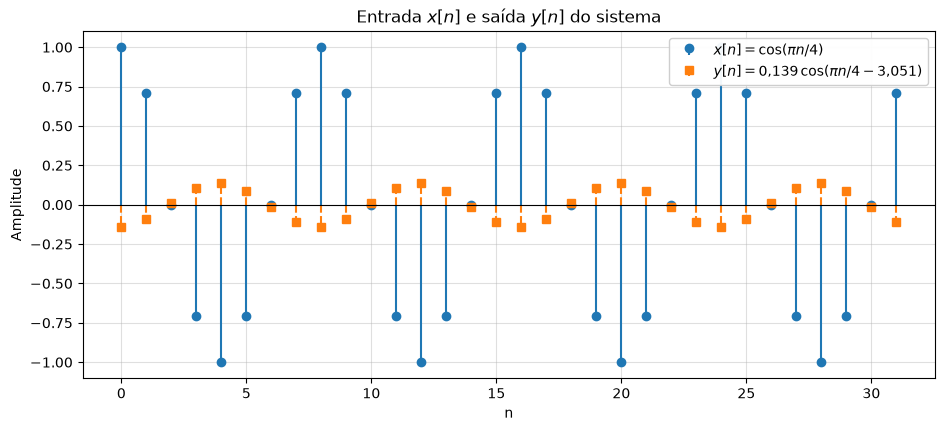

In [12]:
# --- Avaliação de H em w0 = pi/4 (item d) ---
w0 = np.pi/4
H0 = resposta_frequencia(np.array([w0]))[0]
A = np.abs(H0)          # ganho de amplitude
phi = np.angle(H0)      # defasagem (rad)

print(f"|H(e^j pi/4)| = {A:.5f}")
print(f"fase          = {phi:.5f} rad ({np.degrees(phi):.2f} graus)")

# --- Sinais: entrada e saída analítica (regime permanente) ---
n = np.arange(0, 32)
x = np.cos(w0*n)
y = A*np.cos(w0*n + phi)


# --- Validação: iterar a própria equação de diferenças ---
# Aplica-se o cosseno desde n = -n_pre para que o transitório já tenha decaído
# em n = 0, reproduzindo a hipótese de senoide permanente do item (d).
def simula_equacao(n_saida, n_pre=300):
    """Resolve y[n] = 0.038x[n-1] + 0.034x[n-2] + 1.63y[n-1] - 0.70y[n-2]."""
    n_total = np.arange(-n_pre, n_saida[-1] + 1)
    xs = np.cos(w0*n_total)
    ys = np.zeros(len(n_total))
    for i in range(2, len(n_total)):
        ys[i] = (0.038*xs[i-1] + 0.034*xs[i-2]
                 + 1.63*ys[i-1] - 0.70*ys[i-2])
    return ys[np.searchsorted(n_total, n_saida)]


y_sim = simula_equacao(n)
print(f"\nErro máximo entre a fórmula analítica e a equação de diferenças: "
      f"{np.max(np.abs(y - y_sim)):.2e}")

# --- Gráfico ---
plt.figure(figsize=(11, 4.5))
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=' ',
         label=r'$x[n]=\cos(\pi n/4)$')
plt.stem(n, y, linefmt='C1--', markerfmt='C1s', basefmt=' ',
         label=r'$y[n]=0{,}139\,\cos(\pi n/4 - 3{,}051)$')
plt.axhline(0, color='k', lw=0.8)
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.title(r'Entrada $x[n]$ e saída $y[n]$ do sistema')
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right', framealpha=0.95)
plt.savefig(os.path.join(IMAGES_DIR, 'grafico_5_xy.png'), dpi=150, bbox_inches='tight')
plt.show()